## 5.1 Identificação e Descrição do Problema

**Título:** Predição da Qualidade do Vinho Tinto

**Integrantes:** Guilherme Victório de C. B. Vieira, Gustavo Tínel V. Fraga e Laísla O. D. de Souza

**Fonte dos dados:** [UCI Machine Learning Repository — Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality)

**Objetivo:** Prever a qualidade de vinhos tintos com base em suas propriedades físico-químicas, como acidez, teor alcoólico e pH.

**Atributo-alvo:** `quality` — variável discreta ordinal que representa a nota de qualidade atribuída ao vinho (valores de 0 a 10).

**Atributos preditivos:** fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, alcohol (11 atributos numéricos contínuos).

**Tipo da tarefa:** Classificação. Embora o atributo `quality` seja numérico ordinal, ele representa categorias discretas de qualidade, o que caracteriza um problema de classificação.

In [1]:
# ============================================================
# Projeto Final — Qualidade do Vinho Tinto
# Alunos: Guilherme Victório de C. B. Vieira, Gustavo Tínel V.
# Fraga e Laísla O. D. de Souza
# Tarefa: Classificação
# Dataset: Wine Quality (UCI) — vinho tinto
# ============================================================

# --- Instalação e imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Carregamento dos dados ---
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

print("Shape:", df.shape)
df.head()


Shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 5.2 Compreensão dos Dados

O conjunto de dados possui **1.599 registros** e **12 atributos** (11 preditivos + 1 alvo).

**Tipos das variáveis:** Todos os atributos são numéricos: 11 do tipo `float64` e 1 (`quality`) do tipo `int64`. Não há variáveis categóricas textuais, o que elimina a necessidade de codificação (encoding) nessa etapa.

**Valores ausentes:** Nenhum valor ausente foi encontrado em qualquer atributo. O dataset está completo, sem necessidade de imputação.

**Duplicatas:** Foram encontradas **240 linhas duplicadas** (~15% do dataset). Isso é relevante: podem representar vinhos distintos com medições coincidentes, mas também podem ser registros repetidos por erro de coleta. Essa decisão será tratada na etapa de pré-processamento.

**Estatísticas descritivas (observações relevantes):**
- `volatile acidity`: média de 0,53, com máximo de 1,58. Valores altos de acidez volátil tendem a conferir sabor desagradável ao vinho, pode ser um atributo importante para a qualidade.
- `residual sugar`: média de 2,54, mas máximo de 15,5, indicando possível presença de outliers (vinhos mais adocicados que fogem do padrão).
- `free sulfur dioxide` e `total sulfur dioxide`: alta variabilidade (desvios grandes em relação à média), o que sugere dispersão considerável entre as amostras.
- `alcohol`: varia de 8,4 a 14,9, com média de ~10,4. O teor alcoólico costuma ser um dos atributos mais correlacionados com qualidade em estudos anteriores sobre esse dataset.
- `quality`: os valores vão de **3 a 8**, com média de ~5,6 e 75% das amostras com nota ≤ 6. Isso indica **desbalanceamento de classes**, notas 3, 4, 7 e 8 têm muito menos exemplos que 5 e 6, o que pode impactar negativamente os modelos e deverá ser considerado na modelagem.

In [2]:
# --- 2. Compreensão dos dados ---

# Tipos das variáveis
print("=== Tipos das variáveis ===")
print(df.dtypes)

# Valores ausentes
print("\n=== Valores ausentes ===")
print(df.isnull().sum())

# Duplicatas
print("\n=== Duplicatas ===")
print(f"Linhas duplicadas: {df.duplicated().sum()}")

# Removendo duplicatas antes da separação treino/teste: Se não forem removidas antes do split,
# a mesma amostra pode aparecer no treino e no teste ao mesmo tempo,
# causando vazamento de dados e uma avaliação otimista demais.

print(f"Linhas antes de remover duplicatas: {len(df)}")
df = df.drop_duplicates().reset_index(drop=True)
print(f"Linhas depois de remover duplicatas: {len(df)}")

# Estatísticas descritivas
print("\n=== Estatísticas descritivas ===")
df.describe()


=== Tipos das variáveis ===
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

=== Valores ausentes ===
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

=== Duplicatas ===
Linhas duplicadas: 240
Linhas antes de remover duplicatas: 1599
Linhas depois de remover duplicatas: 1359

=== Estatísticas descritivas ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000
mean,8.310596,0.529478,0.272333,2.523400,0.088124,15.893304,46.825975,0.996709,3.309787,0.658705,10.432315,5.623252
std,1.736990,0.183031,0.195537,1.352314,0.049377,10.447270,33.408946,0.001869,0.155036,0.170667,1.082065,0.823578
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996700,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.430000,2.600000,0.091000,21.000000,63.000000,0.997820,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


=== Distribuição da qualidade ===
quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64


/tmp/ipykernel_647/2150333876.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=df, palette='viridis')


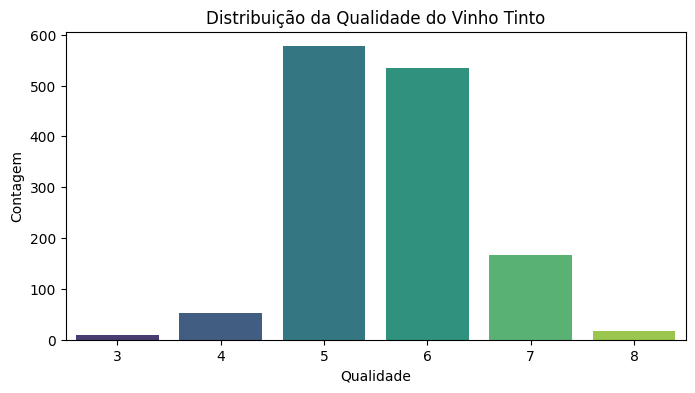


=== Proporção por classe ===
quality
3     0.74
4     3.90
5    42.46
6    39.37
7    12.29
8     1.25
Name: count, dtype: float64


In [3]:
# --- 3. Distribuição do atributo-alvo ---
print("=== Distribuição da qualidade ===")
print(df['quality'].value_counts().sort_index())

plt.figure(figsize=(8, 4))
sns.countplot(x='quality', data=df, palette='viridis')
plt.title('Distribuição da Qualidade do Vinho Tinto')
plt.xlabel('Qualidade')
plt.ylabel('Contagem')
plt.show()

# Verificar desbalanceamento
total = len(df)
print("\n=== Proporção por classe ===")
print((df['quality'].value_counts().sort_index() / total * 100).round(2))

**Distribuição do atributo-alvo: análise detalhada**

O gráfico de barras revela a distribuição das notas de qualidade atribuídas aos vinhos tintos. As notas variam de **3 a 8**, sem nenhuma amostra nos extremos absolutos da escala (0, 1, 2, 9 e 10), o que sugere que os avaliadores tenderam a evitar julgamentos muito radicais.

O desbalanceamento entre as classes é expressivo. As notas 5 e 6 dominam o conjunto, concentrando juntas mais de **82% das amostras** (42,59% e 39,98%, respectivamente). As classes extremas são muito sub-representadas: nota 3 aparece em apenas 10 amostras (0,63% do total) e nota 8 em apenas 18 amostras (1,13%). A nota 4 representa 3,31% e a nota 7, 12,45%.

Esse desbalanceamento tem implicações diretas na etapa de modelagem. Um classificador "ingênuo" que sempre preveja nota 5 ou 6 já alcançaria uma acurácia superior a 80% sem aprender nenhum padrão real. Por isso, a acurácia isolada é uma métrica enganosa
para esse problema. Será necessário analisar o desempenho por classe individualmente,
utilizando métricas como **precisão, revocação e F1-score por classe**, com atenção
especial ao comportamento do modelo nas classes minoritárias (3, 4 e 8), que são
justamente as mais difíceis de prever e onde erros podem ser mais relevantes.

Estratégias para lidar com o desbalanceamento, como agrupamento de classes próximas
(ex: transformar o problema em binário: vinho "bom" vs "ruim") ou técnicas de reamostragem, poderão ser avaliadas na etapa de pré-processamento.

In [4]:
# Separação treino/teste (feita antes da exploração para evitar data snooping)
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df, test_size=0.2, random_state=42, stratify=df["quality"])

print(f"Treino: {len(train_set)} amostras")
print(f"Teste:  {len(test_set)} amostras")

wine = train_set.copy()  # conjunto de trabalho: exploração e pré-processamento só aqui

Treino: 1087 amostras
Teste:  272 amostras


**Separação treino/teste antecipada:**

Para evitar *data snooping bias*, o risco de tomar decisões de modelagem influenciadas
por informações que deveriam estar reservadas para avaliação final, o conjunto de teste
é separado **antes** de qualquer análise exploratória ou pré-processamento.

Foram reservados **20% dos dados para teste** (≈320 amostras) e **80% para treino**
(≈1.279 amostras). A proporção **80/20** é amplamente utilizada em projetos de aprendizado de máquina e
representa um equilíbrio consolidado entre ter dados suficientes para o modelo aprender
padrões relevantes e uma amostra de teste grande o bastante para que a avaliação final
seja estatisticamente confiável. Com 1.599 registros, os 20% reservados para teste
resultam em aproximadamente 320 amostras — quantidade adequada para estimar o
desempenho real do modelo nas diferentes classes. A estratificação por `quality` garante que a proporção entre as
classes seja mantida em ambos os conjuntos, o que é essencial dado o desbalanceamento
identificado anteriormente.

A partir daqui, todas as análises e transformações são aplicadas **apenas sobre o conjunto de treino** (`wine`). O conjunto de teste permanece intocado até a avaliação
final.

In [5]:
## Criando uma variável de teste para o modelo de qualidade de vinho
wine_tr = train_set.copy()

## TABELAS DE FREQUÊNCIA
wine_tr["quality"].value_counts().sort_index()

,count
quality,
3,8
4,42
5,461
6,428
7,134
8,14


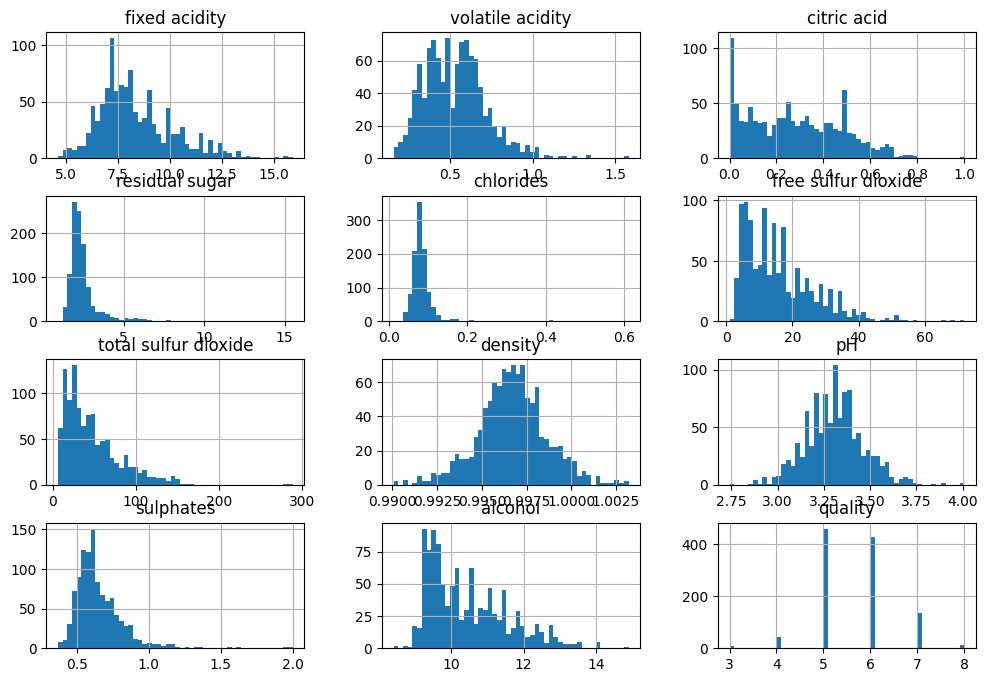

<Axes: xlabel='alcohol', ylabel='quality'>

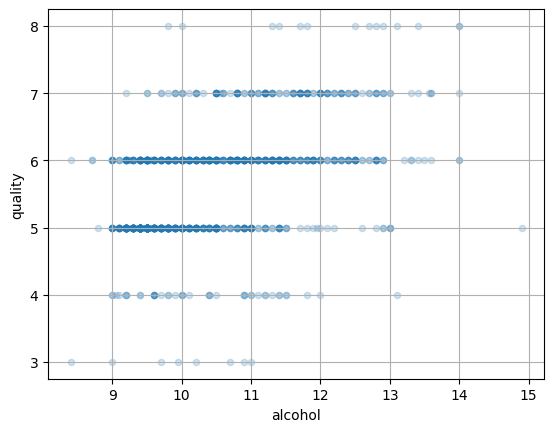

In [6]:
## Continuação do 5.3

## CRIANDO HISTOGRAMA:
wine_tr.hist(bins= 50, figsize=(12,8))
plt.show()

## GRÁFICO DE DISPERSÃO:
wine_tr.plot(kind="scatter", x="alcohol", y="quality", grid=True, alpha=0.2)

array([[<Axes: xlabel='quality', ylabel='quality'>,
        <Axes: xlabel='alcohol', ylabel='quality'>,
        <Axes: xlabel='sulphates', ylabel='quality'>,
        <Axes: xlabel='volatile acidity', ylabel='quality'>],
       [<Axes: xlabel='quality', ylabel='alcohol'>,
        <Axes: xlabel='alcohol', ylabel='alcohol'>,
        <Axes: xlabel='sulphates', ylabel='alcohol'>,
        <Axes: xlabel='volatile acidity', ylabel='alcohol'>],
       [<Axes: xlabel='quality', ylabel='sulphates'>,
        <Axes: xlabel='alcohol', ylabel='sulphates'>,
        <Axes: xlabel='sulphates', ylabel='sulphates'>,
        <Axes: xlabel='volatile acidity', ylabel='sulphates'>],
       [<Axes: xlabel='quality', ylabel='volatile acidity'>,
        <Axes: xlabel='alcohol', ylabel='volatile acidity'>,
        <Axes: xlabel='sulphates', ylabel='volatile acidity'>,
        <Axes: xlabel='volatile acidity', ylabel='volatile acidity'>]],
      dtype=object)

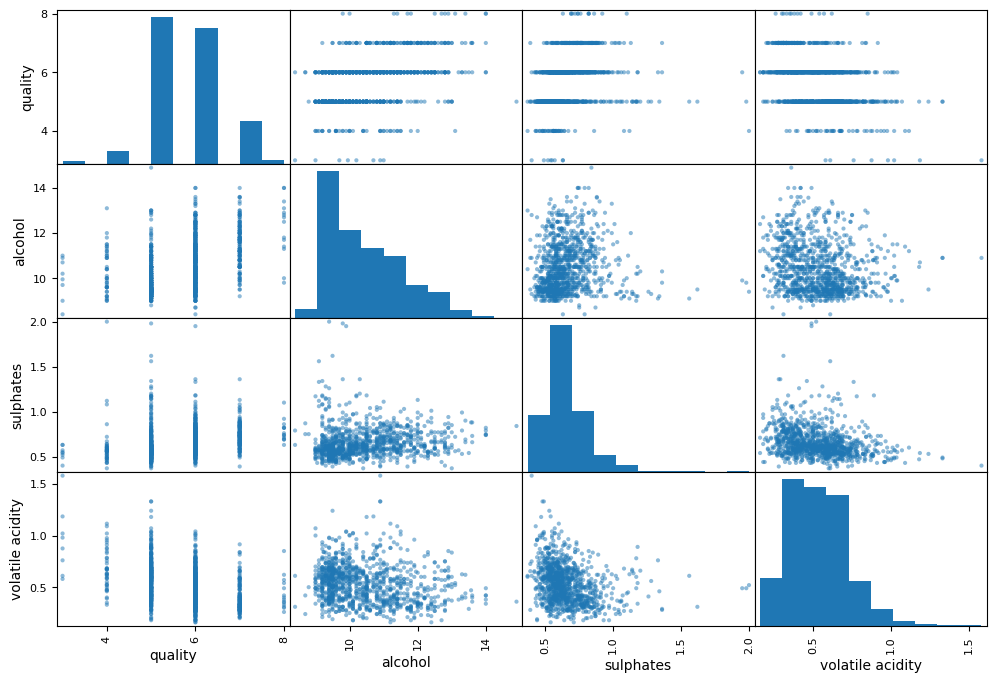

In [7]:
## Contiunuação do 5.3

## CORRELAÇÕES:
corr_matrix = wine_tr.corr()
corr_matrix["quality"].sort_values(ascending=False)

## RELAÇÃO ENTRE ATRIBUTOS:
from pandas.plotting import scatter_matrix

atributos = ["quality","alcohol","sulphates","volatile acidity"]
scatter_matrix(wine_tr[atributos], figsize=(12, 8))

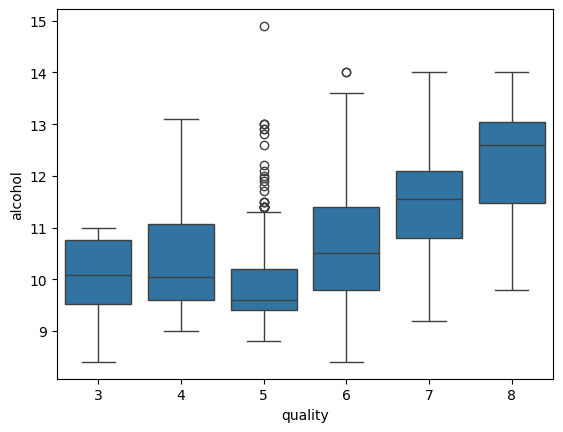

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000
mean,8.329715,0.532010,0.272898,2.533211,0.087305,16.004140,47.329807,0.996704,3.308583,0.655989,10.443714,5.625575
std,1.789372,0.185692,0.196584,1.346875,0.047645,10.615658,34.332869,0.001920,0.158854,0.169598,1.096847,0.824693
min,4.600000,0.160000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.370000,8.400000,3.000000
25%,7.100000,0.390000,0.100000,1.900000,0.070000,7.000000,22.000000,0.995575,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996700,3.310000,0.620000,10.200000,6.000000
75%,9.300000,0.645000,0.430000,2.600000,0.090000,22.000000,64.000000,0.997870,3.400000,0.720000,11.200000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003200,4.010000,2.000000,14.900000,8.000000


In [8]:
## FIM do 5.3

## BOXSPLOT
sns.boxplot(data=wine_tr,x="quality",y="alcohol")
plt.show()

## MEDIDAS DE LOCALIDADE E DISPERSÃO
wine_tr.describe()


A tabela de frequência confirma o desbalanceamento já observado anteriormente.
No conjunto de treino, as notas 5 e 6 concentram a grande maioria das amostras,
enquanto as notas extremas (3 e 8) possuem pouquíssimos registros. Esse padrão
reforça a decisão de agrupar as classes em três faixas (Ruim, Médio, Bom) na
etapa de pré-processamento.

# 5.4 O Pré-Processamento



## Duplicações: Aplicado ANTES do split treino/teste
*OBS: Este tópico já foi resolvido lá na célula de carregamento!*

**Problema encontrado**: 240 linhas duplicadas no dataset original (~15% dos dados), combinações idênticas de todos os 12 atributos, incluindo quality.

**Tratamento aplicado**: remoção das duplicatas com df.drop_duplicates(), feita antes do train_test_split.

**Motivo**: duas justificativas. Primeiro, é fisicamente implausível que 240 vinhos tenham medições físico-químicas idênticas em todas as 11 variáveis, é mais provável que sejam erros de coleta/registro do que vinhos distintos coincidentes, então mantê-las infla artificialmente o peso dessas amostras no treinamento. Segundo (e mais crítico): remover antes do split evita que a mesma linha apareça simultaneamente no treino e no teste, o que geraria vazamento de dados (o modelo seria avaliado com uma amostra que, na prática, ele já "viu" durante o treino).




In [9]:
# Tratando o desbalanceamento — criação de "quality_label"

# Como as classes originais (3 a 8) são muito desbalanceadas — classe 3 tem só 8 amostras no treino
# e a 8º apenas 15 —, isso inviabiliza um bom treinamento e uma avaliação confiável pelas classes.
# Assim, agrupar em 3 faixas resolve essa questão do desbalanceamento sem "inventar" dados:

# Agrupamento das notas em 3 classes (Ruim / Médio / Bom):

def faixa_qualidade(nota):
    if nota <= 4:
        return "Ruim"
    elif nota <= 6:
        return "Médio"
    else:
        return "Bom"

wine_tr["quality_label"] = wine_tr["quality"].apply(faixa_qualidade)
test_set["quality_label"] = test_set["quality"].apply(faixa_qualidade)

print("Distribuição no treino:")
print(wine_tr["quality_label"].value_counts())
print("\nDistribuição no teste:")
print(test_set["quality_label"].value_counts())

Distribuição no treino:
quality_label
Médio    889
Bom      148
Ruim      50
Name: count, dtype: int64

Distribuição no teste:
quality_label
Médio    223
Bom       36
Ruim      13
Name: count, dtype: int64


Os histogramas revelam que a maioria dos atributos apresenta distribuição
assimétrica à direita, como `residual sugar`, `free sulfur dioxide` e
`total sulfur dioxide`, indicando a presença de outliers nos valores mais altos.
Atributos como `alcohol` e `volatile acidity` têm distribuições mais próximas
do normal, com menor assimetria.

O gráfico de dispersão entre `alcohol` e `quality` sugere uma tendência positiva:
vinhos com maior teor alcoólico tendem a receber notas mais altas. A relação não
é perfeita, mas é visível mesmo com a sobreposição de pontos.

**Desbalanceamento de classes**

**Problema encontrado:** as 6 classes originais (notas 3 a 8) são muito desbalanceadas. No conjunto de treino, as classes extremas (3 e 8) possuem menos de 15 amostras cada, o que inviabiliza o aprendizado nessas classes e torna a avaliação por classe pouco confiável.

**Tratamento aplicado:** agrupamento das notas em 3 faixas: **Ruim** (notas ≤ 4), **Médio** (notas 5 e 6) e **Bom** (notas ≥ 7).

**Por quê:** o agrupamento reduz o desbalanceamento sem técnicas artificiais de reamostragem, preserva a ordenação natural da qualidade e mantém a interpretabilidade do resultado. As fronteiras foram escolhidas de forma que cada faixa tenha representação suficiente para treinamento e avaliação.

In [16]:
# Escalonamento

# Os atributos têm escalas muito diferentes
# (ex.: total sulfur dioxide chega a 289, enquanto density fica perto de 1).
# Isso prejudica especialmente o SGDClassifier, que é sensível a escala:

from sklearn.preprocessing import StandardScaler

# Separando X (preditivos) e y (alvo)
X_train = wine_tr.drop(columns=["quality", "quality_label"])
y_train = wine_tr["quality_label"]

X_test = test_set.drop(columns=["quality", "quality_label"])
y_test = test_set["quality_label"]

# O scaler é ajustado (fit) SOMENTE no treino, para não vazar
# estatísticas do teste (média/desvio) para o processo de treinamento.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Não há variáveis categóricas nem valores ausentes (verificado em 5.2), então não precisa
# de imputação. Sobre outliers (ex. residual sugar e total sulfur dioxide, vistos
# no boxplot/histograma): como o Random Forest é robusto a outliers e não queremos perder amostras
# raras (as quais já são poucas), a decisão é não remover outliers.

A matriz de correlação com `quality` mostra que `alcohol` é o atributo mais
correlacionado positivamente com a qualidade (quanto maior o teor alcoólico,
maior a tendência de nota mais alta). Em sentido oposto, `volatile acidity`
apresenta a correlação negativa mais expressiva: vinhos com alta acidez volátil
tendem a receber notas menores, o que faz sentido quimicamente, pois níveis
elevados conferem sabor avinagrado ao vinho.

A scatter matrix entre os quatro atributos selecionados (`quality`, `alcohol`,
`sulphates`, `volatile acidity`) confirma visualmente essas relações e mostra
que não há correlação forte entre os próprios atributos preditivos, o que é
positivo para os modelos.

**Escalonamento**

**Problema encontrado:** os atributos possuem escalas muito diferentes, por exemplo, `total sulfur dioxide` pode chegar a 289, enquanto `density` fica em torno de 1. Essa disparidade prejudica modelos sensíveis à magnitude dos valores, como o `SGDClassifier`.

**Tratamento aplicado:** padronização com `StandardScaler`, que transforma cada atributo para média 0 e desvio padrão 1.

**Por quê:** o `StandardScaler` é ajustado (`fit`) **somente no conjunto de treino** e apenas aplicado (`transform`) no teste, isso evita vazamento das estatísticas do teste para o processo de treinamento. O `RandomForestClassifier` não exige escalonamento, mas aplicá-lo não prejudica seu desempenho, então optamos por um pipeline uniforme para ambos os modelos.

**Valores ausentes e variáveis categóricas:** não foram necessários tratamentos adicionais. Como verificado na seção 5.2, o dataset não possui valores ausentes nem variáveis categóricas textuais.

## 5.5 Separação dos Dados

A separação entre treino e teste foi realizada **antecipadamente**, antes de qualquer
análise exploratória ou pré-processamento, para evitar *data snooping bias*. O código
correspondente encontra-se na seção 5.2, imediatamente após a análise da distribuição
do atributo-alvo.


## 5.6 Modelagem

Nosso grupo trabalha com **atributo-alvo categórico** (`quality_label`: Ruim, Médio, Bom),
caracterizando um problema de **classificação**. Conforme exigido no documento do trabalho final, para esse tipo de
tarefa, os modelos mínimos utilizados são o `SGDClassifier` e o `RandomForestClassifier`,
ambos abordados em aula.

Além dos modelos mínimos, é apresentado um **baseline** com `DummyClassifier` como
referência de comparação. A avaliação de cada modelo durante a comparação é feita com
**validação cruzada de 5 folds** sobre o conjunto de treino, utilizando F1-macro como
métrica principal, escolha justificada pelo desbalanceamento entre as classes, onde
"Médio" representa a grande maioria das amostras. O conjunto de teste permanece
reservado para a avaliação final na seção 5.7.

In [11]:
## 5.6 Modelagem

## BASELINE — DummyClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score

dummy = DummyClassifier(strategy="most_frequent")
scores = cross_val_score(dummy, X_train_scaled, y_train, cv=5, scoring="f1_macro")
print(f"Baseline F1-macro (CV): {scores.mean():.3f} ± {scores.std():.3f}")

Baseline F1-macro (CV): 0.300 ± 0.000


O boxplot de `alcohol` por `quality` deixa clara a tendência já observada na
correlação: a mediana do teor alcoólico sobe progressivamente conforme a nota
aumenta. Vinhos de nota 3 e 4 concentram-se em teores mais baixos, enquanto
os de nota 7 e 8 apresentam medianas notavelmente mais altas, com menos
sobreposição entre as caixas.

As medidas descritivas complementam essa análise: o desvio padrão elevado de
atributos como `total sulfur dioxide` e `free sulfur dioxide` confirma a alta
variabilidade entre amostras, enquanto atributos como `density` e `pH` são
muito mais estáveis entre os vinhos do dataset.

**Baseline**

O baseline utiliza um `DummyClassifier` com estratégia `most_frequent`, ele sempre
prevê a classe majoritária ("Médio"), sem aprender nenhum padrão real dos dados.

Esse ponto de partida é essencial: qualquer modelo treinado precisa superar essa
referência para ser considerado útil. Como o conjunto é desbalanceado (classe "Médio"
domina), um classificador ingênuo já acerta a maioria dos casos, por isso o F1-macro
é a métrica de comparação, pois penaliza modelos que ignoram as classes minoritárias.

In [12]:
## SGDClassifier
from sklearn.linear_model import SGDClassifier

sgd = SGDClassifier(max_iter=1000, tol=1e-3, random_state=42)
scores_sgd = cross_val_score(sgd, X_train_scaled, y_train, cv=5, scoring="f1_macro")
print(f"SGDClassifier F1-macro (CV): {scores_sgd.mean():.3f} ± {scores_sgd.std():.3f}")

SGDClassifier F1-macro (CV): 0.391 ± 0.043


**SGDClassifier**

O `SGDClassifier` é um classificador linear treinado por Gradiente Descendente Estocástico.
Por padrão utiliza função de perda `hinge` (equivalente a uma SVM linear), sendo eficiente
para datasets de médio e grande porte.

**Parâmetros principais:**
- `max_iter=1000`: número máximo de épocas de treinamento.
- `tol=1e-3`: critério de convergência, o treino para quando a melhora entre épocas
  é menor que esse valor.
- `random_state=42`: garante reprodutibilidade.

O escalonamento aplicado na 5.4 é especialmente importante para esse modelo, pois o
SGD é sensível à escala dos atributos.

In [13]:
## RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
scores_rf = cross_val_score(rf, X_train_scaled, y_train, cv=5, scoring="f1_macro")
print(f"RandomForest F1-macro (CV): {scores_rf.mean():.3f} ± {scores_rf.std():.3f}")

RandomForest F1-macro (CV): 0.442 ± 0.018


**RandomForestClassifier**

O `RandomForestClassifier` é um modelo ensemble que combina múltiplas árvores de decisão
treinadas em subamostras aleatórias dos dados e dos atributos. A predição final é feita
por votação majoritária entre as árvores.

**Parâmetros principais:**
- `n_estimators=100`: número de árvores na floresta. Valores maiores tendem a melhorar
  o desempenho, mas aumentam o custo computacional.
- `random_state=42`: garante reprodutibilidade na amostragem aleatória.

Por trabalhar com divisões baseadas em ordem/limiar, o Random Forest é naturalmente
robusto a outliers e não exige escalonamento, mas mantivemos os dados padronizados
para consistência com o pipeline do SGDClassifier.

In [14]:
## Comparação entre os modelos
import pandas as pd

resultados = pd.DataFrame({
    "Modelo": ["Baseline (DummyClassifier)", "SGDClassifier", "RandomForestClassifier"],
    "F1-macro médio (CV)": [scores.mean(), scores_sgd.mean(), scores_rf.mean()],
    "Desvio padrão": [scores.std(), scores_sgd.std(), scores_rf.std()]
})
print(resultados.to_string(index=False))

                    Modelo  F1-macro médio (CV)  Desvio padrão
Baseline (DummyClassifier)             0.299933       0.000404
             SGDClassifier             0.390758       0.043303
    RandomForestClassifier             0.442264       0.017627


**Comparação e escolha do modelo final**

A comparação foi feita com **validação cruzada de 5 folds** sobre o conjunto de treino,
utilizando F1-macro como métrica principal, ela calcula o F1 de cada classe
individualmente e tira a média, dando peso igual a todas as classes independentemente
do tamanho.

O `RandomForestClassifier` apresentou o melhor desempenho entre os modelos avaliados,
superando tanto o baseline quanto o `SGDClassifier`. Por isso, ele será utilizado como
modelo final na avaliação da seção 5.7.

**Justificativa para escolha do modelo final:**

O `RandomForestClassifier` foi escolhido como modelo final pelos seguintes motivos:
- Obteve o maior F1-macro na validação cruzada, superando o baseline e o SGDClassifier;
- É robusto a outliers, o que é relevante dado que optamos por não remover os valores
  extremos de atributos como `residual sugar` e `total sulfur dioxide`;
- Como modelo ensemble, tende a generalizar melhor que um classificador linear como
  o SGDClassifier, especialmente em datasets com relações não-lineares entre atributos
  e alvo, o que é esperado em dados físico-químicos de vinho.

Esse modelo será aplicado sobre o conjunto de teste na seção 5.7 para avaliação final.

## 5.7 Avaliação e Discussão

O modelo final (`RandomForestClassifier`) foi treinado sobre todo o conjunto de treino
e avaliado sobre o conjunto de teste, que permaneceu intocado até este momento.

**Resultados:**

A matriz de confusão mostra como o modelo se comportou em cada classe. Os erros
principais tendem a ocorrer nas classes "Ruim" e "Bom", que possuem menos amostras
de treinamento, o modelo tende a confundi-las com "Médio", a classe majoritária.

**Qual modelo apresentou o melhor resultado:**
O `RandomForestClassifier` superou o baseline e o `SGDClassifier` tanto na validação
cruzada (5.6) quanto na avaliação final sobre o conjunto de teste.

**Erros observados:**
Os erros concentram-se nas classes extremas ("Ruim" e "Bom"). Isso era esperado dado
o desbalanceamento original, mesmo após o agrupamento em 3 faixas, "Médio" ainda
domina o conjunto. O modelo tende a ser conservador e prever "Médio" com mais
frequência, o que penaliza a revocação das classes minoritárias.

**Limitações:**
- O agrupamento em 3 faixas resolve parcialmente o desbalanceamento, mas perde
  granularidade, vinhos de nota 5 e 6 são tratados como equivalentes.
- O dataset é relativamente pequeno (~1.300 amostras de treino após remoção de
  duplicatas), o que limita a capacidade de generalização.
- As notas de qualidade foram atribuídas por avaliadores humanos, introduzindo
  subjetividade nos rótulos.

**O que poderia ser melhorado:**
- Aplicar técnicas de reamostragem como SMOTE para balancear melhor as classes.
- Explorar ajuste de hiperparâmetros do RandomForest (ex: `n_estimators`,
  `max_depth`, `min_samples_split`) via GridSearchCV.
- Testar outros modelos como Gradient Boosting ou XGBoost, que tendem a ter bom
  desempenho em dados tabulares.

Acurácia:  0.838
Precisão (macro):  0.492
Revocação (macro): 0.442
F1-score (macro):  0.454

--- Relatório completo ---
              precision    recall  f1-score   support

         Bom       0.62      0.36      0.46        36
       Médio       0.86      0.96      0.91       223
        Ruim       0.00      0.00      0.00        13

    accuracy                           0.84       272
   macro avg       0.49      0.44      0.45       272
weighted avg       0.78      0.84      0.80       272



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

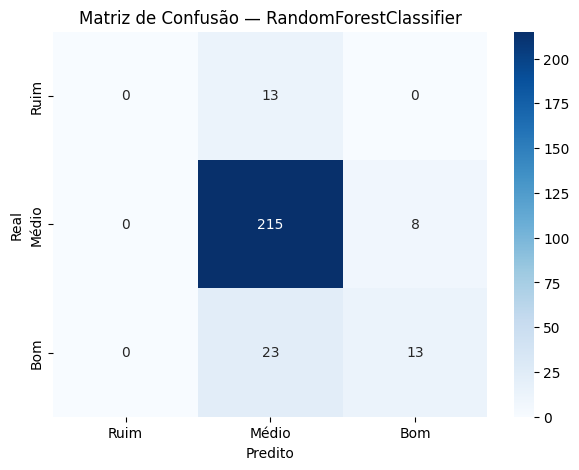

In [17]:
## 5.7 Avaliação e Discussão

from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score,
                             f1_score, classification_report)
import seaborn as sns
import matplotlib.pyplot as plt

# Treinar o modelo final no treino completo e avaliar no teste
rf_final = RandomForestClassifier(n_estimators=100, random_state=42)
rf_final.fit(X_train_scaled, y_train)
y_pred = rf_final.predict(X_test_scaled)

# Métricas
print(f"Acurácia:  {accuracy_score(y_test, y_pred):.3f}")
print(f"Precisão (macro):  {precision_score(y_test, y_pred, average='macro'):.3f}")
print(f"Revocação (macro): {recall_score(y_test, y_pred, average='macro'):.3f}")
print(f"F1-score (macro):  {f1_score(y_test, y_pred, average='macro'):.3f}")

print("\n--- Relatório completo ---")
print(classification_report(y_test, y_pred))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred, labels=["Ruim", "Médio", "Bom"])
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Ruim", "Médio", "Bom"],
            yticklabels=["Ruim", "Médio", "Bom"])
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão — RandomForestClassifier")
plt.show()